In [1]:
import sys
sys.path.insert(0, "..")

In [2]:
!git clone https://github.com/facebookresearch/vjepa2.git
import sys
import os
repo_path = '/content/vjepa2'

if repo_path not in sys.path:
    sys.path.append(repo_path)

Cloning into 'vjepa2'...
remote: Enumerating objects: 449, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 449 (delta 18), reused 14 (delta 14), pack-reused 407 (from 2)
Receiving objects: 100% (449/449), 7.72 MiB | 17.18 MiB/s, done.
Resolving deltas: 100% (198/198), done.


In [3]:
!cat /content/vjepa2/src/hub/backbones.py

# Copyright (c) Meta Platforms, Inc. and affiliates.
#
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

import torch

# VJEPA_BASE_URL = "https://dl.fbaipublicfiles.com/vjepa2"

# for testing
VJEPA_BASE_URL = "http://localhost:8300"

ARCH_NAME_MAP = {
    # V-JEPA 2
    "vit_large": ("vit_large", "vitl"),
    "vit_huge": ("vit_huge", "vith"),
    "vit_giant": ("vit_giant_xformers", "vitg"),
    "vit_ac_giant": ("vit_giant_xformers", "vjepa2-ac-vitg"),
    "vit_giant_384": ("vit_giant_xformers", "vitg-384"),
    # V-JEPA 2.1
    "vjepa2_1_vit_base_384": ("vit_base", "vjepa2_1_vitb_dist_vitG_384"),
    "vjepa2_1_vit_large_384": ("vit_large", "vjepa2_1_vitl_dist_vitG_384"),
    "vjepa2_1_vit_giant_384": ("vit_giant_xformers", "vjepa2_1_vitg_384"),
    "vjepa2_1_vit_gigantic_384": ("vit_gigantic_xformers", "vjepa2_1_vitG_384"),
}


def _clean_backbone_key(state_dict):
    for key, val in state_dict.copy().items():


In [4]:
!cat /content/vjepa2/src/models/vision_transformer.py

# Copyright (c) Meta Platforms, Inc. and affiliates.
#
# This source code is licensed under the MIT license found in the
# LICENSE file in the root directory of this source tree.

import math
from functools import partial

import torch
import torch.nn as nn

from src.masks.utils import apply_masks
from src.models.utils.modules import Block
from src.models.utils.patch_embed import PatchEmbed, PatchEmbed3D
from src.models.utils.pos_embs import get_2d_sincos_pos_embed, get_3d_sincos_pos_embed
from src.utils.tensors import trunc_normal_


class VisionTransformer(nn.Module):
    """Vision Transformer"""

    def __init__(
        self,
        img_size=(224, 224),
        patch_size=16,
        num_frames=1,
        tubelet_size=2,
        in_chans=3,
        embed_dim=768,
        depth=12,
        num_heads=12,
        mlp_ratio=4.0,
        qkv_bias=True,
        qk_scale=None,
        drop_rate=0.0,
        attn_drop_rate=0.0,
        drop_path_rate=0.0,
        norm_layer=nn.LayerNorm,

In [5]:
import sys
import os

repo_root = '/content/vjepa2'

if os.path.exists(repo_root):
    if repo_root not in sys.path:
        sys.path.append(repo_root)
    os.chdir(repo_root)
    print(f"✅: {os.getcwd()}")
else:
    print(f"❌: {repo_root}")
print("Now:", [f for f in os.listdir('.') if os.path.isdir(f)])

✅: /content/vjepa2
Now: ['app', 'assets', 'src', 'evals', 'notebooks', 'tests', '.github', '.git', 'configs']


In [6]:
import sys
import os

repo_root = '/content/vjepa2'

src_path = os.path.join(repo_root, 'src')

if src_path not in sys.path:
    sys.path.insert(0, src_path)

if repo_root not in sys.path:
    sys.path.insert(1, repo_root)

os.chdir(repo_root)

test_file = os.path.join(src_path, 'utils/mpc_utils.py')
if os.path.exists(test_file):
    print(f"🎯: {test_file}")
else:
    import glob
    found = glob.glob(f"{repo_root}/**/mpc_utils.py", recursive=True)
    if found:
        actual_parent = os.path.dirname(os.path.dirname(found[0]))
        sys.path.insert(0, actual_parent)
        print(f"✅ : {actual_parent}")

try:
    from app.vjepa_droid.transforms import make_transforms
    from utils.mpc_utils import compute_new_pose, poses_to_diff
    print("🚀 ！")
except ImportError as e:
    print(f"❌: {e}")

✅ : /content/vjepa2/notebooks
🚀 ！


In [7]:
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.nn import functional as F

import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src')) # Add src to sys.path

from app.vjepa_droid.transforms import make_transforms
from utils.mpc_utils import (
    compute_new_pose,
    poses_to_diff
)

In [8]:
!wget https://dl.fbaipublicfiles.com/vjepa2/vjepa2-ac-vitg.pt -P /content/

--2026-03-31 01:21:56--  https://dl.fbaipublicfiles.com/vjepa2/vjepa2-ac-vitg.pt
Resolving dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)... 13.249.182.39, 13.249.182.81, 13.249.182.33, ...
Connecting to dl.fbaipublicfiles.com (dl.fbaipublicfiles.com)|13.249.182.39|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11760743310 (11G) [application/xml]
Saving to: ‘/content/vjepa2-ac-vitg.pt’

vjepa2-ac-vitg.pt   100%[===================>]  10.95G   226MB/s    in 49s     

2026-03-31 01:22:45 (229 MB/s) - ‘/content/vjepa2-ac-vitg.pt’ saved [11760743310/11760743310]



In [9]:
import torch
import os
import sys

repo_root = '/content/vjepa2'
src_path = os.path.join(repo_root, 'src')

# Clean up sys.path to prioritize local repo
# Remove any paths related to torch.hub's cache if they exist
sys.path = [p for p in sys.path if 'torch/hub' not in p]

# Ensure local repo_root and src_path are at the beginning of sys.path
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# If the module was already incorrectly loaded from torch.hub, remove it from sys.modules
module_to_clear = 'src.models.vision_transformer'
if module_to_clear in sys.modules:
    # Check if the module's file path indicates it came from torch.hub cache
    module_file = getattr(sys.modules[module_to_clear], '__file__', '')
    if '/root/.cache/torch/hub/' in module_file:
        print(f"Clearing '{module_to_clear}' from sys.modules to force reload from local repository.")
        del sys.modules[module_to_clear]

# Import the model builder and the cleaning function from backbones.py
from src.hub.backbones import _make_vjepa2_ac_model, _clean_backbone_key

# Import transform (already defined in the original cell, needs to be imported)
from app.vjepa_droid.transforms import make_transforms

# Initialize VJEPA 2-AC model
crop_size = 256

# Use _make_vjepa2_ac_model to build the encoder and predictor architectures.
# Set pretrained=False because we will load weights manually from our local checkpoint.
encoder, predictor = _make_vjepa2_ac_model(
    model_name="vit_ac_giant",
    img_size=crop_size,
    pretrained=False,
)

# Calculate tokens_per_frame based on encoder's patch_size
tokens_per_frame = int((crop_size // encoder.patch_size) ** 2)

# 3. Load weights from the manually downloaded checkpoint
checkpoint_path = "/content/vjepa2-ac-vitg.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu")

# V-JEPA checkpoints often contain 'encoder' and 'predictor' keys
if 'encoder' in checkpoint and 'predictor' in checkpoint:
    # Apply _clean_backbone_key to remove 'module.' prefix before loading
    encoder_state_dict = _clean_backbone_key(checkpoint['encoder'])
    predictor_state_dict = _clean_backbone_key(checkpoint['predictor'])
    encoder.load_state_dict(encoder_state_dict, strict=False) # strict=False to allow for minor mismatches if any
    predictor.load_state_dict(predictor_state_dict, strict=True)
elif 'state_dict' in checkpoint: # Handle cases where weights are nested under 'state_dict'
    encoder_state_dict = {k.replace("encoder.", ""): v for k, v in checkpoint['state_dict'].items() if k.startswith("encoder.")}
    predictor_state_dict = {k.replace("predictor.", ""): v for k, v in checkpoint['state_dict'].items() if k.startswith("predictor.")}
    if encoder_state_dict:
        encoder_state_dict = _clean_backbone_key(encoder_state_dict)
        encoder.load_state_dict(encoder_state_dict, strict=False)
    if predictor_state_dict:
        predictor_state_dict = _clean_backbone_key(predictor_state_dict)
        predictor.load_state_dict(predictor_state_dict, strict=True)
else:
    # Fallback: try loading directly into encoder if checkpoint format is simpler
    try:
        cleaned_checkpoint = _clean_backbone_key(checkpoint)
        encoder.load_state_dict(cleaned_checkpoint, strict=False)
        print("Warning: Loaded checkpoint directly into encoder. Predictor might not be initialized with pre-trained weights.")
    except RuntimeError as e:
        print(f"Error loading checkpoint directly into encoder: {e}")
        print("Please check the checkpoint structure or the model initialization.")

# Move models to CUDA and set to evaluation mode
encoder.cuda().eval()
predictor.cuda().eval()
print("✅ Encoder and Predictor loaded successfully from local checkpoint!")

# Initialize transform (the rest of the original cell content)
transform = make_transforms(
    random_horizontal_flip=False,
    random_resize_aspect_ratio=(1., 1.),
    random_resize_scale=(1., 1.),
    reprob=0.,
    auto_augment=False,
    motion_shift=False,
    crop_size=crop_size,
)

/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


✅ Encoder and Predictor loaded successfully from local checkpoint!


In [11]:
# Load robot trajectory

play_in_reverse = False  # Use this FLAG to try loading the trajectory backwards, and see how the energy landscape changes

trajectory = np.load("/content/vjepa2/notebooks/franka_example_traj.npz")
np_clips = trajectory["observations"]
np_states = trajectory["states"]
if play_in_reverse:
    np_clips = trajectory["observations"][:, ::-1].copy()
    np_states = trajectory["states"][:, ::-1].copy()
np_actions = np.expand_dims(poses_to_diff(np_states[0, 0], np_states[0, 1]), axis=(0, 1))

# Convert trajectory to torch tensors
clips = transform(np_clips[0]).unsqueeze(0)
states = torch.tensor(np_states)
actions = torch.tensor(np_actions)
print(f"clips: {clips.shape}; states: {states.shape}; actions: {actions.shape}")

clips: torch.Size([1, 3, 2, 256, 256]); states: torch.Size([1, 2, 7]); actions: torch.Size([1, 1, 7])


In [12]:
!ls -F /content/vjepa2

APACHE-LICENSE	    configs/	     notebooks/		    setup.py
app/		    CONTRIBUTING.md  pyproject.toml	    src/
assets/		    evals/	     README.md		    tests/
CHANGELOG.md	    hubconf.py	     requirements-test.txt
CODE_OF_CONDUCT.md  LICENSE	     requirements.txt


In [13]:
!ls -F /content/vjepa2/notebooks/

energy_landscape_example.ipynb	utils/		   vjepa2_demo.py
franka_example_traj.npz		vjepa2_demo.ipynb


In [14]:
# Load robot trajectory
# No need to wget, as the file is already in the repository

play_in_reverse = False  # Use this FLAG to try loading the trajectory backwards, and see how the energy landscape changes

trajectory = np.load("/content/vjepa2/notebooks/franka_example_traj.npz")
np_clips = trajectory["observations"]
np_states = trajectory["states"]
if play_in_reverse:
    np_clips = trajectory["observations"][:, ::-1].copy()
    np_states = trajectory["states"][:, ::-1].copy()
np_actions = np.expand_dims(poses_to_diff(np_states[0, 0], np_states[0, 1]), axis=(0, 1))

# Convert trajectory to torch tensors
clips = transform(np_clips[0]).unsqueeze(0).cuda() # Move clips to CUDA
states = torch.tensor(np_states).cuda() # Move states to CUDA
actions = torch.tensor(np_actions).cuda() # Move actions to CUDA
print(f"clips: {clips.shape}; states: {states.shape}; actions: {actions.shape}")

clips: torch.Size([1, 3, 2, 256, 256]); states: torch.Size([1, 2, 7]); actions: torch.Size([1, 1, 7])


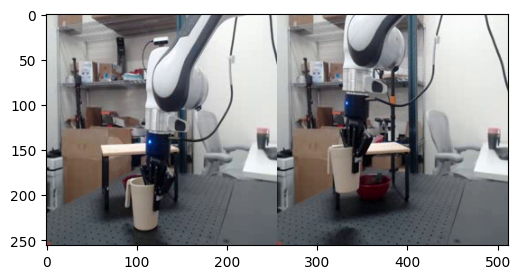

In [15]:
# Visualize loaded video frames from traj

T = len(np_clips[0])
plt.figure(figsize=(20, 3))
_ = plt.imshow(np.transpose(np_clips[0], (1, 0, 2, 3)).reshape(256, 256 * T, 3))

In [16]:
def forward_target(c, normalize_reps=True):
    B, C, T, H, W = c.size()
    c = c.permute(0, 2, 1, 3, 4).flatten(0, 1).unsqueeze(2).repeat(1, 1, 2, 1, 1)
    h = encoder(c)
    h = h.view(B, T, -1, h.size(-1)).flatten(1, 2)
    if normalize_reps:
        h = F.layer_norm(h, (h.size(-1),))
    return h


def forward_actions(z, nsamples, grid_size=0.075, normalize_reps=True, action_repeat=1):

    def make_action_grid(grid_size=grid_size):
        action_samples = []
        for da in np.linspace(-grid_size, grid_size, nsamples):
            for db in np.linspace(-grid_size, grid_size, nsamples):
                for dc in np.linspace(-grid_size, grid_size, nsamples):
                    action_samples += [torch.tensor([da, db, dc, 0, 0, 0, 0], device=z.device, dtype=z.dtype)]
        return torch.stack(action_samples, dim=0).unsqueeze(1)

    # Sample grid of actions
    action_samples = make_action_grid()
    print(f"Sampled grid of actions; num actions = {len(action_samples)}")

    def step_predictor(_z, _a, _s):
        _z = predictor(_z, _a, _s)[:, -tokens_per_frame:]
        if normalize_reps:
            _z = F.layer_norm(_z, (_z.size(-1),))
        _s = compute_new_pose(_s[:, -1:], _a[:, -1:])
        return _z, _s

    # Context frame rep and context pose
    z_hat = z[:, :tokens_per_frame].repeat(int(nsamples**3), 1, 1)  # [S, N, D]
    s_hat = states[:, :1].repeat((int(nsamples**3), 1, 1))  # [S, 1, 7]
    a_hat = action_samples  # [S, 1, 7]

    for _ in range(action_repeat):
        _z, _s = step_predictor(z_hat, a_hat, s_hat)
        z_hat = torch.cat([z_hat, _z], dim=1)
        s_hat = torch.cat([s_hat, _s], dim=1)
        a_hat = torch.cat([a_hat, action_samples], dim=1)

    return z_hat, s_hat, a_hat

def loss_fn(z, h):
    z, h = z[:, -tokens_per_frame:], h[:, -tokens_per_frame:]
    loss = torch.abs(z - h)  # [B, N, D]
    loss = torch.mean(loss, dim=[1, 2])
    return loss.tolist()

In [17]:
# Compute energy for cartesian action grid of size (nsample x nsamples x nsamples)
nsamples = 5
grid_size = 0.075
with torch.no_grad():
    h = forward_target(clips)
    z_hat, s_hat, a_hat = forward_actions(h, nsamples=nsamples, grid_size=grid_size)
    loss = loss_fn(z_hat, h)  # jepa prediction loss

/usr/lib/python3.12/contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)


Sampled grid of actions; num actions = 125


Ground truth action (x,y,z) = (0.09,0.03,0.08)


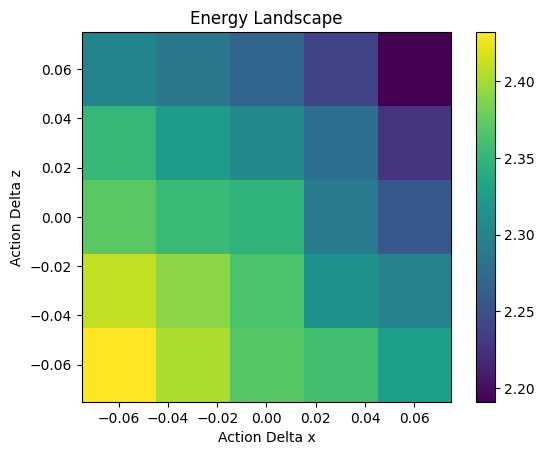

In [18]:
# Plot the energy

plot_data = []
for b, v in enumerate(loss):
    plot_data.append((
        a_hat[b, :-1, 0].sum().cpu().item(), # Move to CPU and get scalar value
        a_hat[b, :-1, 1].sum().cpu().item(), # Move to CPU and get scalar value
        a_hat[b, :-1, 2].sum().cpu().item(), # Move to CPU and get scalar value
        v,
    ))

delta_x = [d[0] for d in plot_data]
delta_y = [d[1] for d in plot_data]
delta_z = [d[2] for d in plot_data]
energy = [d[3] for d in plot_data]

gt_x = actions[0, 0, 0].cpu().item() # Move to CPU and get scalar value
gt_y = actions[0, 0, 1].cpu().item() # Move to CPU and get scalar value
gt_z = actions[0, 0, 2].cpu().item() # Move to CPU and get scalar value

# Create the 2D histogram
heatmap, xedges, yedges = np.histogram2d(delta_x, delta_z, weights=energy, bins=nsamples)

# Set axis labels
plt.xlabel("Action Delta x")
plt.ylabel("Action Delta z")
plt.title(f"Energy Landscape")

# Display the heatmap
print(f"Ground truth action (x,y,z) = ({gt_x:.2f},{gt_y:.2f},{gt_z:.2f})")
_ = plt.imshow(heatmap.T, origin="lower", extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], cmap="viridis")
_ = plt.colorbar()

In [19]:
# Compute the optimal action using MPC
from utils.world_model_wrapper import WorldModel

world_model = WorldModel(
    encoder=encoder,
    predictor=predictor,
    tokens_per_frame=tokens_per_frame,
    transform=transform,
    # Doing very few CEM iterations with very few samples just to run efficiently on CPU...
    # ... increase cem_steps and samples for more accurate optimization of energy landscape
    mpc_args={
        "rollout": 2,
        "samples": 25,
        "topk": 10,
        "cem_steps": 2,
        "momentum_mean": 0.15,
        "momentum_mean_gripper": 0.15,
        "momentum_std": 0.75,
        "momentum_std_gripper": 0.15,
        "maxnorm": 0.075,
        "verbose": True
    },
    normalize_reps=True,
    device="cpu"
)

with torch.no_grad():
    h = forward_target(clips)
    z_n, z_goal = h[:, :tokens_per_frame], h[:, -tokens_per_frame:]
    s_n = states[:, :1]
    print(f"Starting planning using Cross-Entropy Method...")
    actions = world_model.infer_next_action(z_n, s_n, z_goal).cpu().numpy()

print(f"Actions returned by planning with CEM (x,y,z) = ({actions[0, 0]:.2f},{actions[0, 1]:.2f} {actions[0, 2]:.2f})")

Starting planning using Cross-Entropy Method...
[INFO    ][2026-03-31 01:28:27][utils.mpc_utils     ][cem                      ] new mean: tensor([-0.0002,  0.0067,  0.0509,  0.0156], device='cuda:0') tensor([0.1380, 0.1413, 0.1337, 1.2614], device='cuda:0')
[INFO    ][2026-03-31 01:28:29][utils.mpc_utils     ][cem                      ] new mean: tensor([ 0.0549,  0.0402,  0.0481, -0.2825], device='cuda:0') tensor([0.1259, 0.1326, 0.1207, 0.8172], device='cuda:0')
Actions returned by planning with CEM (x,y,z) = (0.05,0.02 0.05)
